In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from tqdm import tqdm

# record start time
_START_RUNTIME = time.time()

# set seed
seed = 24
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

In [2]:
DATA_PATH = '/Users/soheilgolara/Downloads/Project/PyHealth/DL4H_alzheimers_cnn/Data/Process'
import os
os.chdir(DATA_PATH)

In [ ]:
!ls -F

DataProcess-1.ipynb               val/
train/                            val-20260322T184314Z-1-001.zip
train-20260322T183659Z-1-001.zip


In [ ]:
import torch.utils.data as data

def get_balanced_indices(full_dataset, ratio_nondemented=0.2, seed=24):
    nondemented_indices = []
    demented_indices = []

    # Determine class indices based on the dataset's class_to_idx
    class_to_idx = full_dataset.class_to_idx

    if 'aNonDemented' in class_to_idx:
        nondemented_label_idx = class_to_idx['aNonDemented']
    else:
        raise ValueError("Class 'aNonDemented' not found in dataset classes.")

    if 'zModerateDementia' in class_to_idx:
        demented_label_idx = class_to_idx['zModerateDementia']
    else:
        raise ValueError("Class 'zModerateDementia' not found in dataset classes.")

    for i, target_label_idx in enumerate(full_dataset.targets):
        if target_label_idx == nondemented_label_idx:
            nondemented_indices.append(i)
        elif target_label_idx == demented_label_idx:
            demented_indices.append(i)

    num_nondemented_to_keep = int(ratio_nondemented * len(nondemented_indices))

    # Shuffle and sample
    random.seed(seed) # Ensure reproducibility for sampling
    sampled_nondemented_indices = random.sample(nondemented_indices, num_nondemented_to_keep)

    return demented_indices + sampled_nondemented_indices

In [ ]:
#output
# train_loader: train data loader (type: torch.utils.data.DataLoader)
# val_loader: val data loader (type: torch.utils.data.DataLoader)
def load_data():

    '''
    TODO: Implement this function to return the data loader for
    train and validation dataset. Set batchsize to 32.

    You should add the following transforms (https://pytorch.org/vision/stable/transforms.html):
        1. transforms.RandomResizedCrop: the images should be cropped to 224 x 224
        2. transforms.ToTensor: just to convert data/labels to tensors
    You should set the *shuffle* flag for *train_loader* to be True, and False for *val_loader*.

    HINT: Consider using `torchvision.datasets.ImageFolder`.
    '''

    import torchvision
    import torchvision.datasets as datasets
    import torchvision.transforms as transforms

    # your code here
    # your code here
    transform = transforms.Compose([
        transforms.Resize([248, 496]),  # Resize to the specified dimensions
        transforms.CenterCrop([248, 496]),  # Crop to the specified dimensions (ensures exact size)
        transforms.ToTensor()
    ])

    full_train_data= datasets.ImageFolder(
            root = f"{DATA_PATH}/train",
            transform = transform
    )
    full_val_data= datasets.ImageFolder(
            root = f"{DATA_PATH}/val",
            transform = transform
    )

    # Print initial class distribution
    print("\n--- Original Dataset Class Distribution ---")
    train_nondemented_full = sum(1 for target in full_train_data.targets if target == full_train_data.class_to_idx['aNonDemented'])
    train_demented_full = sum(1 for target in full_train_data.targets if target == full_train_data.class_to_idx['zModerateDementia'])
    print(f"Train Full: NonDemented={train_nondemented_full}, ModerateDementia={train_demented_full}")

    val_nondemented_full = sum(1 for target in full_val_data.targets if target == full_val_data.class_to_idx['aNonDemented'])
    val_demented_full = sum(1 for target in full_val_data.targets if target == full_val_data.class_to_idx['zModerateDementia'])
    print(f"Val Full: NonDemented={val_nondemented_full}, ModerateDementia={val_demented_full}")

    # Apply balancing to training data
    # Assuming 'seed' is globally defined from earlier cell NaZrCNL2OzkJ
    balanced_train_indices = get_balanced_indices(full_train_data, seed=seed)
    train_data = data.Subset(full_train_data, balanced_train_indices)

    # Apply balancing to validation data
    balanced_val_indices = get_balanced_indices(full_val_data, seed=seed)
    val_data = data.Subset(full_val_data, balanced_val_indices)

    # Print class distribution after balancing
    print("\n--- Balanced Dataset Class Distribution ---")
    train_nondemented_balanced = sum(1 for idx in balanced_train_indices if full_train_data.targets[idx] == full_train_data.class_to_idx['aNonDemented'])
    train_demented_balanced = sum(1 for idx in balanced_train_indices if full_train_data.targets[idx] == full_train_data.class_to_idx['zModerateDementia'])
    print(f"Train Balanced: NonDemented={train_nondemented_balanced}, ModerateDementia={train_demented_balanced}")

    val_nondemented_balanced = sum(1 for idx in balanced_val_indices if full_val_data.targets[idx] == full_val_data.class_to_idx['aNonDemented'])
    val_demented_balanced = sum(1 for idx in balanced_val_indices if full_val_data.targets[idx] == full_val_data.class_to_idx['zModerateDementia'])
    print(f"Val Balanced: NonDemented={val_nondemented_balanced}, ModerateDementia={val_demented_balanced}")


    print("", full_train_data.classes)
    print("train_data.class_to_idx", full_train_data.class_to_idx)

    train_loader= torch.utils.data.DataLoader(train_data, batch_size=8, shuffle=True)
    val_loader= torch.utils.data.DataLoader(val_data, batch_size=8, shuffle=True)

    return train_loader, val_loader


--- Original Dataset Class Distribution ---
Train Full: NonDemented=54596, ModerateDementia=390
Val Full: NonDemented=13650, ModerateDementia=98

--- Balanced Dataset Class Distribution ---
Train Balanced: NonDemented=10919, ModerateDementia=390
Val Balanced: NonDemented=2730, ModerateDementia=98
 ['aNonDemented', 'zModerateDementia']
train_data.class_to_idx {'aNonDemented': 0, 'zModerateDementia': 1}
labels tensor([0, 0, 0, 0, 0, 0, 0, 0])


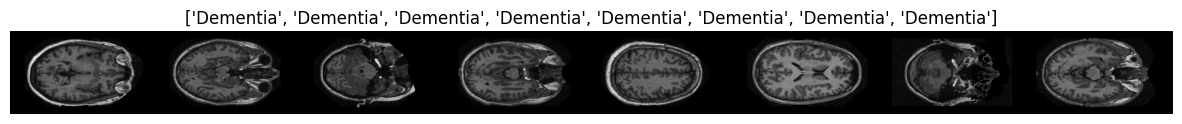

labels tensor([0, 0, 0, 0, 0, 0, 0, 0])


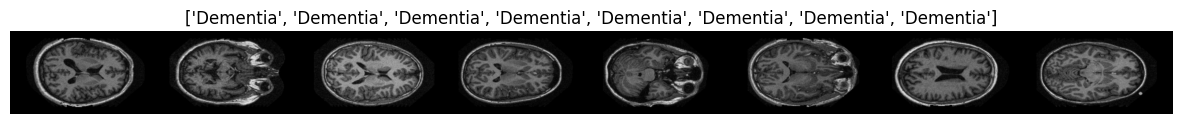

In [ ]:
import torchvision
import matplotlib.pyplot as plt


def imshow(img, title):
    npimg = img.numpy()
    plt.figure(figsize=(15, 7))
    plt.axis('off')
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.show()

def show_batch_images(dataloader, k=8):
    images, labels = next(iter(dataloader))
    images = images[:k]
    labels = labels[:k]
    print("labels",labels)
    img = torchvision.utils.make_grid(images, padding=25)
    imshow(img, title=["Dementia" if x==0  else "NonDementia" for x in labels])

train_loader, val_loader = load_data()
for i in range(2):
    show_batch_images(train_loader)

In [ ]:
def save_processed_dataset(loader, filename="train_data.pt"):
    all_imgs = []
    all_labels = []

    print(f"Packing {len(loader.dataset)} images into {filename}...")
    for imgs, labels in loader:
        all_imgs.append(imgs)
        all_labels.append(labels)

    # Stack into giant tensors
    data_dict = {
        'imgs': torch.cat(all_imgs),
        'labels': torch.cat(all_labels)
    }
    torch.save(data_dict, filename)
    print("Done!")

def load_fast_data(filename):
    data = torch.load(filename)
    dataset = torch.utils.data.TensorDataset(data['imgs'], data['labels'])
    return torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)

from torch.utils.data import TensorDataset, DataLoader

def load_from_pt(train_path="balanced_train.pt", val_path="balanced_val.pt"):
    # Load the tensors directly into memory
    train_data = torch.load(train_path)
    val_data = torch.load(val_path)

    # Reconstruct the datasets
    train_ds = TensorDataset(train_data['imgs'], train_data['labels'])
    val_ds = TensorDataset(val_data['imgs'], val_data['labels'])

    # Create loaders
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

    return train_loader, val_loader

In [ ]:
train_loader, val_loader = load_data()


--- Original Dataset Class Distribution ---
Train Full: NonDemented=54596, ModerateDementia=390
Val Full: NonDemented=13650, ModerateDementia=98

--- Balanced Dataset Class Distribution ---
Train Balanced: NonDemented=10919, ModerateDementia=390
Val Balanced: NonDemented=2730, ModerateDementia=98
 ['aNonDemented', 'zModerateDementia']
train_data.class_to_idx {'aNonDemented': 0, 'zModerateDementia': 1}


In [ ]:
save_processed_dataset(train_loader, "balanced_train_0p2.pt")

Packing 11309 images into balanced_train_0p2.pt...


In [ ]:
save_processed_dataset(val_loader, "balanced_val_0p2.pt")

Packing 2828 images into balanced_val_0p2.pt...
Done!
